## Importing Dependancies

In [87]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
dataset = pd.read_csv('heart_disease_data.csv')

In [62]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [63]:
dataset.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [64]:
dataset.shape

(303, 14)

In [65]:
## Getting info on the data 

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [66]:
## checking for missing values 
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [67]:
### Describing the data

dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [68]:
## checking distribution for targest variable

dataset['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

*1* --> Defective Heart

0 --> Healthy Heart

#### Splitting the Features and Target

In [69]:
predictors = dataset.drop(columns='target', axis=1)
response = dataset['target']

In [70]:
print(predictors)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [71]:
print(response)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


#### Splitting the Data into Training data & Test Data

In [72]:
predictors_train, predictors_test, response_train, response_test = train_test_split(predictors, response, test_size=0.2, stratify=response, random_state=2)

In [73]:
print(predictors.shape, predictors_train.shape, predictors_test.shape)

(303, 13) (242, 13) (61, 13)


## Model Training


#### Logistic Regression

In [74]:
model = LogisticRegression()

In [75]:
# training the LogisticRegression model with Training data
model.fit(predictors_train, response_train)

C:\Users\d16b119\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Model Evaluation

#### Accuracy on training Data 

In [76]:
predictors_train_prediction = model.predict(predictors_train)
training_data_accuracy = accuracy_score(predictors_train_prediction, response_train)
y_pred_prob = model.predict_proba(predictors_train)[:,1] # probability for class 1

In [77]:

accuracy = accuracy_score(predictors_train_prediction, response_train)
precision = precision_score(predictors_train_prediction, response_train)
recall = recall_score(predictors_train_prediction, response_train)
f1 = f1_score(predictors_train_prediction, response_train)
roc_auc = roc_auc_score(predictors_train_prediction, y_pred_prob)
cm = confusion_matrix(predictors_train_prediction, response_train)

print("Classification Model Evaluation:")
print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-score: {f1:.5f}")
print(f"ROC-AUC: {roc_auc:.5f}")
print("Confusion Matrix:")
print(cm)

Classification Model Evaluation:
Accuracy: 0.851
Precision: 0.917
Recall: 0.829
F1-score: 0.871
ROC-AUC: 1.000
Confusion Matrix:
[[ 85  11]
 [ 25 121]]


### Accuracy on testing data

In [79]:
# accuracy on test data
predictors_test_prediction = model.predict(predictors_test)
test_data_accuracy = accuracy_score(predictors_test_prediction, response_test)
y_test_prob = model.predict_proba(predictors_test)[:,1] # probability for class 1

In [80]:
accuracy = accuracy_score(predictors_test_prediction, response_test)
precision = precision_score(predictors_test_prediction, response_test)
recall = recall_score(predictors_test_prediction, response_test)
f1 = f1_score(predictors_test_prediction, response_test)
roc_auc = roc_auc_score(predictors_test_prediction, y_test_prob)
cm = confusion_matrix(predictors_test_prediction, response_test)

print("Classification Model Evaluation:")
print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1-score: {f1:.5f}")
print(f"ROC-AUC: {roc_auc:.5f}")
print("Confusion Matrix:")
print(cm)

Classification Model Evaluation:
Accuracy: 0.81967
Precision: 0.81818
Recall: 0.84375
F1-score: 0.83077
ROC-AUC: 1.00000
Confusion Matrix:
[[23  6]
 [ 5 27]]


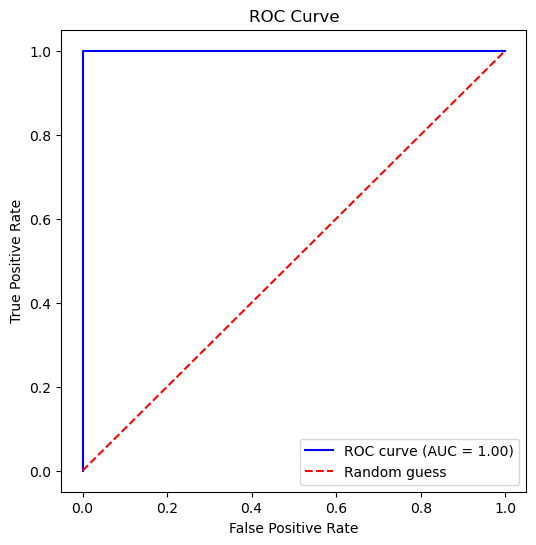

In [81]:
fpr, tpr, thresholds = roc_curve(predictors_train_prediction, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Metrics

In [89]:
rmse = mean_squared_error(predictors_train_prediction, response_train)
r2 = r2_score(predictors_train_prediction, response_train)
print(f"RMSE: {rmse:.5f}, R²: {r2:.5f}")



RMSE: 0.14876, R²: 0.37842


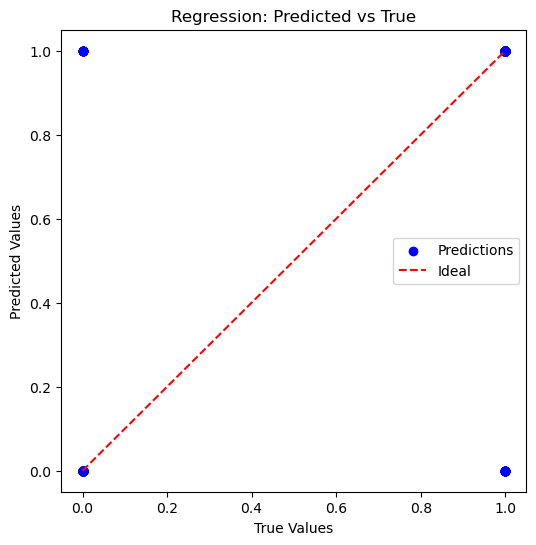

In [92]:
# Plot predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(predictors_train_prediction,response_train, color='blue', label='Predictions')
plt.plot([min(predictors_train_prediction), max(predictors_train_prediction)], [min(predictors_train_prediction), max(predictors_train_prediction)], color='red', linestyle='--', label='Ideal')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Regression: Predicted vs True")
plt.legend()
plt.show()

### Building a Predictive System

In [ ]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

In [ ]:
The Person does not have a Heart Disease